# ***Practical 2 - Gradient descent principles***

<span style="font-size:18px"><em>Authors:</em> Guillem Calvo and Oscar Romero</span>

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

## ***1. Gradient descent methods***

### ***1.1. A simple quadratic function***

In this first part, we analyze a simple two-dimensional quadratic function:

$$\boxed{f(x_1,x_2) = x_1^2 + x_2^2}$$

whose minimum is trivially located at $(x_1,x_2)=(0,0)$.

To find this minimum computationally, we are going to implement the gradient descent algorithm, using:

$$\mathbf{x}^{k+1} = \mathbf{x}^k-\alpha^k\nabla f(\mathbf{x}^k)$$

with a constant $\alpha^k=0.1$ and a hundred iterations. We will start from different intial points (not too far from the origin) to analyze how the algorithm behaves.

Gradient Descent Results performing 100 iterations:
Starting point: [-0.5  1. ], Final point: [-1.01851799e-10  2.03703598e-10]
Starting point: [-1.5  0. ], Final point: [-3.05555396e-10  0.00000000e+00]
Starting point: [ 1.3 -1.5], Final point: [ 2.64814677e-10 -3.05555396e-10]
Starting point: [0.7 0.5], Final point: [1.42592518e-10 1.01851799e-10]
Starting point: [-0.25 -0.5 ], Final point: [-5.09258994e-11 -1.01851799e-10]


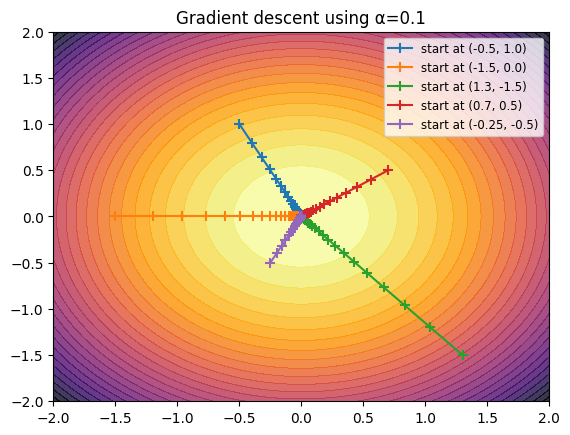

In [3]:
def f(x):
    return x[0]**2 + x[1]**2

def grad_f(x):
    return np.array([2*x[0], 2*x[1]])

def gradient_descent(x0, alpha=0.1, max_iter=100):
    x = x0
    path = [x]
    for _ in range(max_iter):
        x = x - alpha * grad_f(x)
        path.append(x)
    return np.array(path)

# Defining initial points
initial_points = [np.array([-0.5, 1]),
                  np.array([-1.5, 0]),
                  np.array([1.3, -1.5]),
                  np.array([0.7, 0.5]),
                  np.array([-0.25, -0.5])]

# Countour lines plot
x1 = np.linspace(-2, 2, 400)
x2 = np.linspace(-2, 2, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = X1**2 + X2**2

plt.contourf(X1, X2, Z, levels=30, cmap=cm.inferno_r, alpha=0.8)

print("Gradient Descent Results performing 100 iterations:")

# Path of each initial point
for x0 in initial_points:
    path = gradient_descent(x0, alpha=0.1)
    plt.plot(path[:,0], path[:,1], marker="+", markersize=7, markeredgewidth=1.5, label=f"start at ({x0[0]}, {x0[1]})")
    print(f"Starting point: {x0}, Final point: {path[-1]}")

#plt.scatter(0,0,color="red",s=100,label="minima (0,0)")
plt.legend(fontsize=8.5)
plt.title("Gradient descent using α=0.1")
plt.show()


Let's do the same now, but with only 50 and 25 iterations

50 ITERATIONS:


Starting point: [-0.5  1. ], Final point: [-7.13623846e-06  1.42724769e-05]
Starting point: [-1.5  0. ], Final point: [-2.14087154e-05  0.00000000e+00]
Starting point: [ 1.3 -1.5], Final point: [ 1.85542200e-05 -2.14087154e-05]
Starting point: [0.7 0.5], Final point: [9.99073385e-06 7.13623846e-06]
Starting point: [-0.25 -0.5 ], Final point: [-3.56811923e-06 -7.13623846e-06]


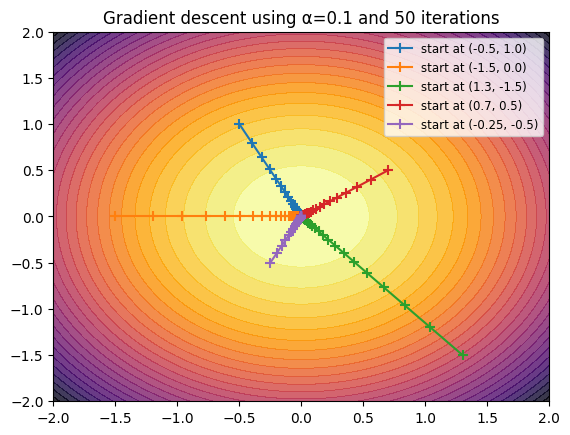

25 ITERATIONS:
Starting point: [-0.5  1. ], Final point: [-0.00188895  0.00377789]
Starting point: [-1.5  0. ], Final point: [-0.00566684  0.        ]
Starting point: [ 1.3 -1.5], Final point: [ 0.00491126 -0.00566684]
Starting point: [0.7 0.5], Final point: [0.00264453 0.00188895]
Starting point: [-0.25 -0.5 ], Final point: [-0.00094447 -0.00188895]


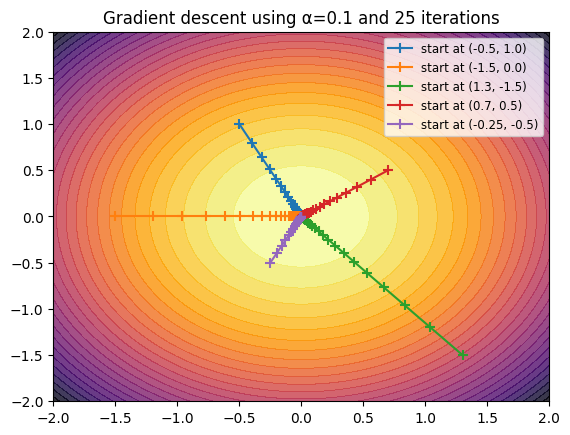

In [4]:
print("50 ITERATIONS:")
plt.contourf(X1, X2, Z, levels=30, cmap=cm.inferno_r, alpha=0.8)

# Path of each initial point
for x0 in initial_points:
    path = gradient_descent(x0, alpha=0.1, max_iter=50)
    plt.plot(path[:,0], path[:,1], marker="+", markersize=7, markeredgewidth=1.5, label=f"start at ({x0[0]}, {x0[1]})")
    print(f"Starting point: {x0}, Final point: {path[-1]}")


plt.legend(fontsize=8.5)
plt.title("Gradient descent using α=0.1 and 50 iterations")
plt.show()

print("25 ITERATIONS:")
plt.contourf(X1, X2, Z, levels=30, cmap=cm.inferno_r, alpha=0.8)

# Path of each initial point
for x0 in initial_points:
    path = gradient_descent(x0, alpha=0.1, max_iter=25)
    plt.plot(path[:,0], path[:,1], marker="+", markersize=7, markeredgewidth=1.5, label=f"start at ({x0[0]}, {x0[1]})")
    print(f"Starting point: {x0}, Final point: {path[-1]}")

plt.legend(fontsize=8.5)
plt.title("Gradient descent using α=0.1 and 25 iterations")
plt.show()

When comparing the three cases, the plots show that the behavior is analogous in all of them: the algorithm consistently converges towards the minimum. However, if we look closely at the final points, we can observe that reducing the number of iterations decreases the precision. With 100 iterations, the final values are on the order of $10^{-10}$; with 50 iterations, around $10^{-5}$; and with 25 iterations, approximately $10^{-3}$.

This confirms that the algorithm approaches the minimum progressively as the number of iterations increases.

Let’s now see what happens when we keep using a constant step size $\alpha$ but with larger values, specifically $\alpha^k=1$ and $\alpha^k=2$.

USING ALPHA=1
Starting point: [-0.5  1. ], Final point: [-0.5  1. ]
Starting point: [-1.5  0. ], Final point: [-1.5  0. ]
Starting point: [ 1.3 -1.5], Final point: [ 1.3 -1.5]
Starting point: [0.7 0.5], Final point: [0.7 0.5]
Starting point: [-0.25 -0.5 ], Final point: [-0.25 -0.5 ]


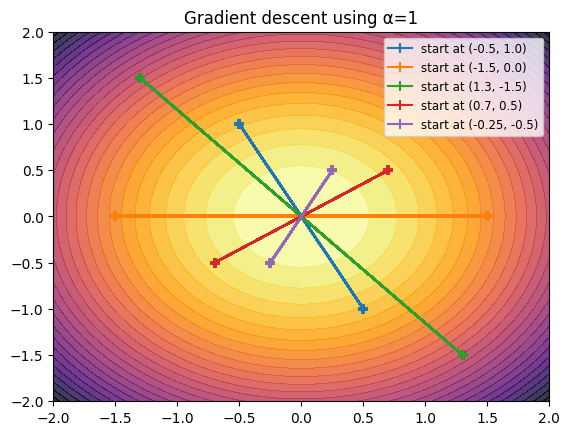

USING ALPHA=2
Starting point: [-0.5  1. ], Final point: [-2.57688760e+47  5.15377521e+47]
Starting point: [-1.5  0. ], Final point: [-7.73066281e+47  0.00000000e+00]
Starting point: [ 1.3 -1.5], Final point: [ 6.69990777e+47 -7.73066281e+47]
Starting point: [0.7 0.5], Final point: [3.60764265e+47 2.57688760e+47]
Starting point: [-0.25 -0.5 ], Final point: [-1.2884438e+47 -2.5768876e+47]


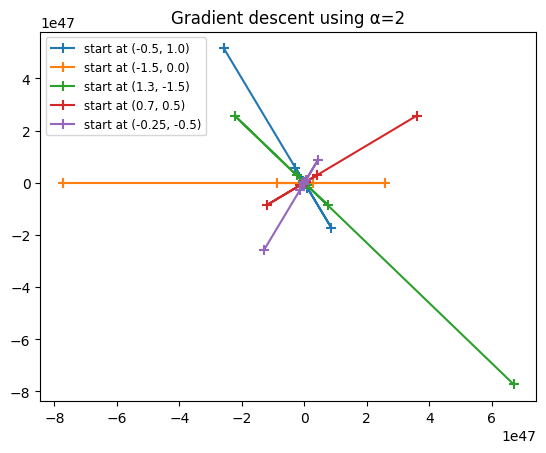

In [5]:
#100 iterations again using alpha=1 & alpha=2

plt.contourf(X1, X2, Z, levels=30, cmap=cm.inferno_r, alpha=0.8)

print('USING ALPHA=1')
for x0 in initial_points:
    path = gradient_descent(x0, alpha=1)
    plt.plot(path[:,0], path[:,1], marker="+", markersize=7, markeredgewidth=1.5, label=f"start at ({x0[0]}, {x0[1]})")
    print(f"Starting point: {x0}, Final point: {path[-1]}")

plt.legend(fontsize=8.5)
plt.title("Gradient descent using α=1")
plt.show()

plt.contourf(X1, X2, Z, levels=30, cmap=cm.inferno_r, alpha=0.8)

print('USING ALPHA=2')
for x0 in initial_points:
    path = gradient_descent(x0, alpha=2)
    plt.plot(path[:,0], path[:,1], marker="+", markersize=7, markeredgewidth=1.5, label=f"start at ({x0[0]}, {x0[1]})")
    print(f"Starting point: {x0}, Final point: {path[-1]}")

plt.legend(fontsize=8.5)
plt.title("Gradient descent using α=2")
plt.show()

With $\alpha=1$, the algorithm literally takes steps proportional to the value of the gradient, jumping from one side of the parabola to the other without settling down — it keeps oscillating around the minimum.

With $\alpha=2$, each step is proportional to twice the gradient, so the algorithm always overshoots the minimum and moves to points with increasingly larger gradient values. As a result, after 100 iterations, the function values grow exponentially, reaching the order of $10^{47}$, so clearly the algorithm diverges with such a huge $\alpha$.

This shows the importance of choosing an appropriate value for $\alpha$.

### ***1.2. A function with multiple minima***

Let's consider now a function with multiple minima:

$$\boxed{f(x_1,x_2) = x_1^2(4 - 2.1x_1^2 + \frac{1}{3}x_1^4) + x_1x_2 + x_2^2(-4 + 4x_2^2)}$$

Before proceeding with the gradient descent implementation, we first create a contour plot together with a 3D surface plot to get an idea of the shape of the function and draw some initial conclusions about the effects of applying the same algorithm to a function with multiple minima.

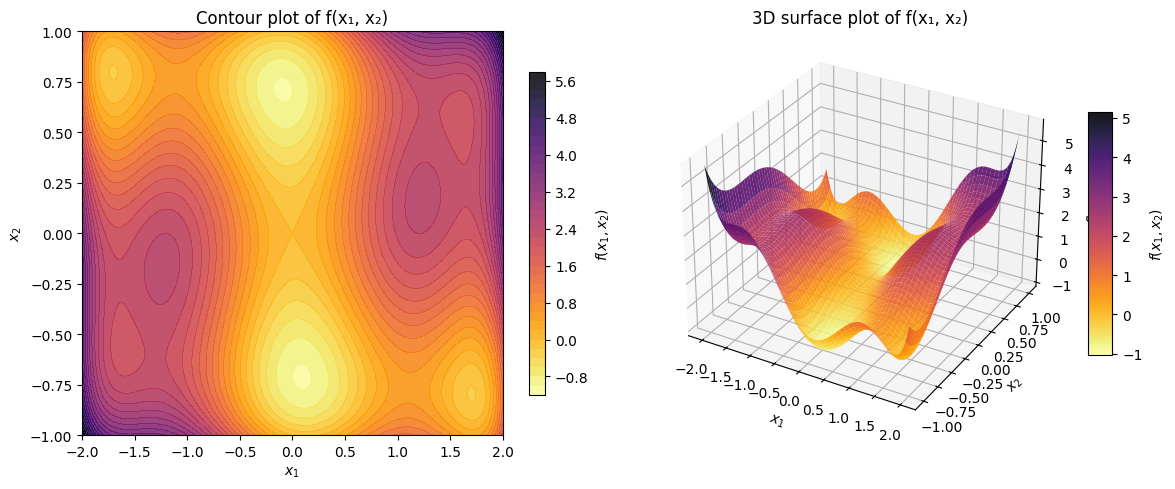

In [6]:
#Function 
def f2(x1, x2):
    return x1**2 * (4 - 2.1 * x1**2 + (x1**4)/3) + x1 * x2 + x2**2 * (-4 + 4 * x2**2)

x1 = np.linspace(-2, 2, 400)
x2 = np.linspace(-1, 1, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = f2(X1, X2)

fig = plt.figure(figsize=(12,5))

# Countour plot
ax1 = fig.add_subplot(1, 2, 1)
contours = ax1.contourf(X1, X2, Z, levels=40, cmap=cm.inferno_r, alpha=0.85)
ax1.set_title("Contour plot of f(x₁, x₂)")
ax1.set_xlabel("$x_1$")
ax1.set_ylabel("$x_2$")
fig.colorbar(contours, ax=ax1, shrink=0.8, label='$f(x_1, x_2)$')


# 3D surface plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(X1, X2, Z, cmap=cm.inferno_r, edgecolor='none', alpha=0.9)
ax2.set_title("3D surface plot of f(x₁, x₂)")
ax2.set_xlabel("$x_1$")
ax2.set_ylabel("$x_2$")
ax2.set_zlabel("$f(x_1, x_2)$")
fig.colorbar(surf, ax=ax2, shrink=0.6, aspect=10, label='$f(x_1, x_2)$')

plt.tight_layout()
plt.show()


Regarding which minimum will be found, we can see that this function is indeed more complex and presents several local minima. Therefore, when using the gradient descent method with an appropriate step size $\alpha$, the final point obtained will depend on the chosen starting point.

Unlike the previous case, the initial point now influences the result, since the algorithm follows the direction of the gradient and consequently converges to the minimum within the valley where it starts.
In a simple parabola, the gradient at any point always points directly towards the global minimum of the function. However, for more complex functions, this no longer holds true, and we need to take additional factors into account.

To verify this, we will implement the gradient descent algorithm on this function starting from different initial points.

Starting point: [-1.25 -0.5 ], Final point: [ 0.08984201 -0.7126564 ], f(final point)=-1.0316284534898774
Starting point: [-1.3  0. ], Final point: [-1.62209202  0.90948131], f(final point)=0.01103624117856794
Starting point: [1.5 0. ], Final point: [ 1.75451546 -0.59562251], f(final point)=0.17635378758853593
Starting point: [0.7 0.5], Final point: [-0.08984201  0.7126564 ], f(final point)=-1.0316284534898774
Starting point: [1.1 0. ], Final point: [ 0.08984201 -0.7126564 ], f(final point)=-1.0316284534898774
Starting point: [0 0], Final point: [0. 0.], f(final point)=0.0
Starting point: [-0.5  0.8], Final point: [-0.08984201  0.7126564 ], f(final point)=-1.0316284534898774


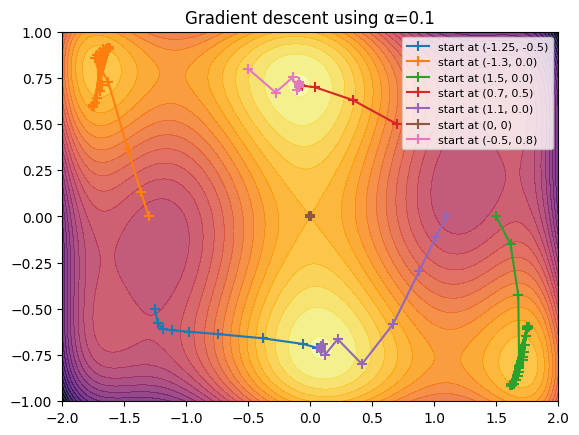

In [7]:
# Function and gradient
def f2(x):
    return (x[0]**2 * (4 - 2.1*x[0]**2 + (1/3)*x[0]**4) + 
            x[0]*x[1] + 
            x[1]**2 * (-4 + 4*x[1]**2))

def grad_f2(x):
    x1, x2 = float(x[0]), float(x[1])
    g1 = (2*x1 * (4 - 2.1*x1**2 + (1/3)*x1**4)
          + x1**2 * (-4.2*x1 + (4/3)*x1**3)
          + x2)
    g2 = x1 + 2*x2 * (-4 + 4*x2**2) + x2**2 * (8*x2)
    return np.array([g1, g2])

#Defining gradient descent algorithm
def gradient_descent_f2(x0, alpha=0.1, max_iter=100):
    x = x0
    path = [x]
    for _ in range(max_iter):
        x = x - alpha * grad_f2(x)
        path.append(x)
    return np.array(path)

# Punts inicials
initial_points = [np.array([-1.25,-0.5]),
                  np.array([-1.3, 0]),
                  np.array([1.5, 0]),
                  np.array([0.7, 0.5]),
                  np.array([1.1, 0]),
                  np.array([0, 0]),
                  np.array([-0.5, 0.8])]


x1 = np.linspace(-2, 2, 400)
x2 = np.linspace(-1, 1, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = f2([X1, X2])

plt.contourf(X1, X2, Z, levels=30, cmap=cm.inferno_r, alpha=0.8)

for x0 in initial_points:
    path = gradient_descent_f2(x0, alpha=0.1)
    plt.plot(path[:,0], path[:,1], marker="+", markersize=7, markeredgewidth=1.5, label=f"start at ({x0[0]}, {x0[1]})")
    print(f"Starting point: {x0}, Final point: {path[-1]}, f(final point)={f2(path[-1])}")

plt.legend(fontsize=8)
plt.title("Gradient descent using α=0.1")
plt.show()

As predicted from the behavior of the algorithm, the convergence strongly depends on the chosen starting point. Depending on the initial position, the algorithm converges to a different local minimum.
To determine whether the algorithm has converged to a local or to the global minimum, we may start from multiple initial points and compare the final function values. The smallest one corresponds to the global minimum.

If we check the results, we have found two global minima at points $(0.08984201, 0.7126564)$ and $(0.08984201, -0.7126564)$.

A special case occurs when the initial point is the origin. In this function, the origin is a saddle point, so even though it is not a minimum, the gradient at that point is zero $\left( \nabla f(0)=0 \right)$. As a result, the update rule $x_{k+1} = x_{k}-\alpha^k \nabla f(x_k)$ produces no change, and $\ x_k = x_{k+1}, \ \forall k\in \mathbb{N}$.

Up to this point, we have always considered a constant value for the step parameter $\alpha$. However, this is not always efficient. In fact, in the last plot we can see that for some initial points, the path followed by the algorithm oscillates significantly around the minimum before converging.  

To improve this behavior, we will slightly modify the algorithm so that the value of $\alpha$ becomes **adaptive**. The idea is to start each iteration with $\alpha_k = 1$ and repeatedly reduce its value by dividing it by 2 (updating $\alpha^k:=\alpha^k/2$) until the following condition is satisfied:  

$$
f(\mathbf{x}_k - \alpha_k \nabla f(\mathbf{x}_k)) < f(\mathbf{x}_k)
$$

Once this condition holds, the update step is performed as usual. This approach, known as a **backtracking line search**, ensures that each iteration produces a decrease in the function value, leading to a more stable and efficient convergence.


In [8]:
def gradient_descent_f2_adapt(x0, alpha=1, tol_grad=1e-05, tol_x=1e-03, max_iters=10000, max_backtracks=50):
    x = np.array(x0, dtype=float)
    path = [x.copy()]
    k=0

    while k < max_iters:
        g = grad_f2(x)
        y = x - alpha * g
        beta=alpha

        div_lim = 0
        while f2(y)>=f2(x):
            beta = beta/2
            y = x-(beta)*g
            div_lim += 1
            if div_lim >= max_backtracks:
                print("Maximum backtracks reached for initial point:", x0)
                break
                      
        if np.linalg.norm(x-y)<tol_x or np.linalg.norm(grad_f2(y))<tol_grad:
            break
        x=y
        k+=1
        path.append(x.copy())
    # return (np.array(path), y, k)
    return np.array(path), k, alpha


In [9]:
initial_points = [np.array([-1.25,-0.5]),
                  np.array([-1.3, 0]),
                  np.array([1.5, 0]),
                  np.array([0.7, 0.5]),
                  np.array([1.1, 0]),
                  np.array([0, 0]),
                  np.array([-0.5, 0.8])]

paths = []
ks = []
# final_alphas = []

# Bucle sobre tots els punts inicials
for x0 in initial_points:
    path, k, alpha = gradient_descent_f2_adapt(x0)
    paths.append(path)
    ks.append(k)
    # final_alphas.append(alpha)

Maximum backtracks reached for initial point: [0 0]


Starting point: [-1.25 -0.5 ], Final point: [-0.09006607  0.71272689], iterations: 9
Starting point: [-1.3  0. ], Final point: [-1.70383849  0.79545304], iterations: 5
Starting point: [1.5 0. ], Final point: [ 1.70376702 -0.79574909], iterations: 7
Starting point: [0.7 0.5], Final point: [-0.09055455  0.71281444], iterations: 5
Starting point: [1.1 0. ], Final point: [-0.08982611  0.71258161], iterations: 7
Maximum backtracks reached for initial point: [0 0]
Starting point: [0 0], Final point: [0. 0.], iterations: 0
Starting point: [-0.5  0.8], Final point: [-0.08968807  0.71268738], iterations: 6


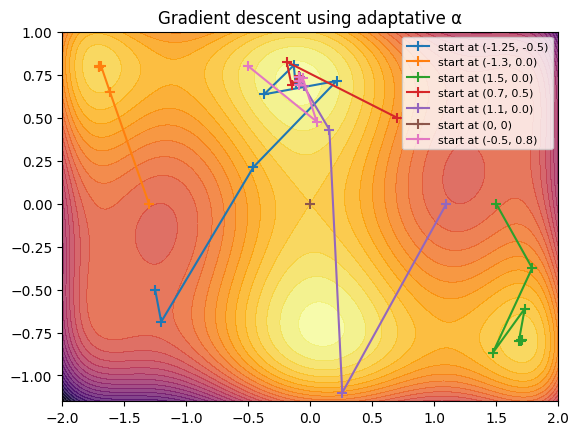

In [10]:
x1 = np.linspace(-2, 2, 400)
x2 = np.linspace(-1.15, 1, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = f2([X1, X2])

plt.contourf(X1, X2, Z, levels=30, cmap=cm.inferno_r, alpha=0.8)

for x0 in initial_points:
    path, k, last_alpha = gradient_descent_f2_adapt(x0)
    plt.plot(path[:,0], path[:,1], marker="+", markersize=7, markeredgewidth=1.5, label=f"start at ({x0[0]}, {x0[1]})")
    print(f"Starting point: {x0}, Final point: {path[-1]}, iterations: {k}") # final alpha: {last_alpha}")

plt.legend(fontsize=8)
plt.title("Gradient descent using adaptative α")
plt.show()


We used the same initial points as in the previous case, and we can verify that using an adaptive step size $\alpha_k$ the algorithm required far fewer than 100 iterations to reach the desired precision (specifically, fewer than 10 in all the tested cases).  

Once again, there is the special case of the initial point $\mathbf{x}_0=(0, 0)$, which corresponds to a saddle point of the function. Since the gradient is zero $\left( \nabla f({\mathbf{x}_0})=0\right)$, the first update step  

$$
\mathbf{x}_{1} = \mathbf{x}_0 - \alpha_k \nabla f(\mathbf{x}_0)
$$  

produces no change. As a consequence, the next iteration falls back to the same point, so $f(\mathbf{x}_{1}) = f(\mathbf{x}_0)$ and the condition for decrease is never satisfied.  
The algorithm therefore keeps halving $\alpha_k$ until it reaches the backtracking limit (set at 50 reductions), at which point the loop stops automatically.

### ***1.3. The Rosenbruck function***

To study what does happen when the variables of the function are not well-scale, we will analyze this optimization methods through the Rosenbruck function:

$$\boxed{
f(x,y) = (a - x)^2 + b (y - x^2)^2}
$$

Let's start calculating its gradient:

$$
\nabla f(x,y) =
\begin{pmatrix}
\frac{\partial f}{\partial x} \\
\frac{\partial f}{\partial y}
\end{pmatrix}
=
\begin{pmatrix}
2a(x - 1) - 4bx(y - x^2) \\
2b (y - x^2)
\end{pmatrix}
$$

In this exercise we will take $\boxed{a=1}$ and $\boxed{b=100}$ for the Rosenbruck function.

In [11]:
def rosenbrock(x, a=1, b=100):
    x1, x2 = x
    return (a - x1)**2 + b * (x2 - x1**2)**2

def rosenbrock_grad(x, a=1, b=100): 
    #GRADIENT
    x1, x2 = x
    dfdx1 = 2*a * (x1 - 1) - 4*b * x1 * (x2 - x1**2)
    dfdx2 = 2*b * (x2 - x1**2)
    G = np.array([dfdx1, dfdx2])
    return G

As we did in the previous sections, we first create a contour plot and a 3D surface plot of the function to get an initial understanding of its nature and to better interpret the behavior of the algorithm later on.
In the plots, we also represent the known minimum of the function, located at $(x_1^*, x_2^*) = (1, 1)$.

c:\Users\Miki\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


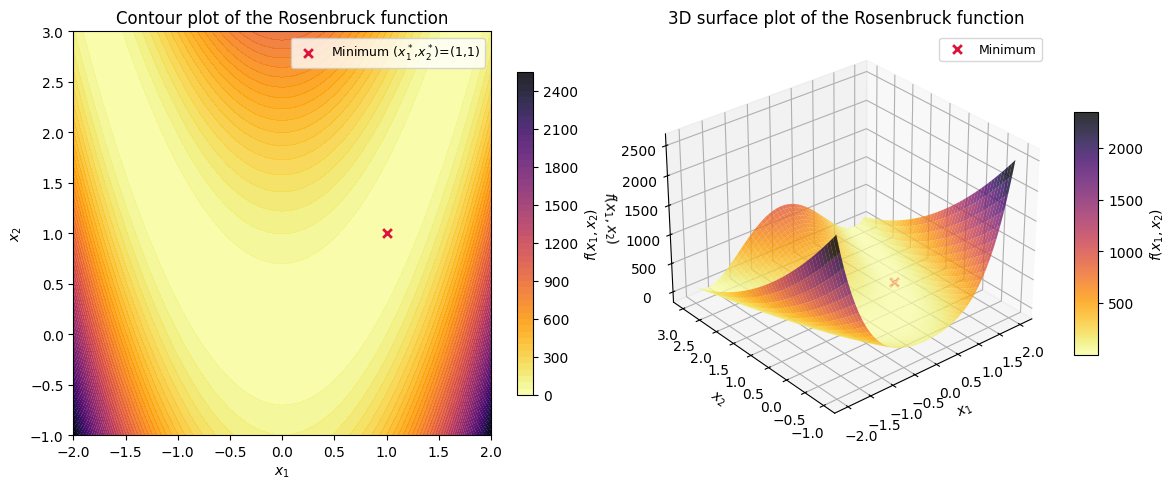

In [12]:
x1 = np.linspace(-2, 2, 200)
x2 = np.linspace(-1, 3, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = rosenbrock((X1, X2))

fig = plt.figure(figsize=(12,5))

# Countour plot
ax1 = fig.add_subplot(1, 2, 1)
contours = ax1.contourf(X1, X2, Z, levels=50, cmap=cm.inferno_r, alpha=0.85)
ax1.set_title("Contour plot of the Rosenbruck function")
ax1.set_xlabel("$x_1$")
ax1.set_ylabel("$x_2$")
ax1.scatter(1, 1, color='crimson', s=40, marker='x', lw=2, label="Minimum ($x_1^*$,$x_2^*$)=(1,1)")
ax1.legend(fontsize=9)
fig.colorbar(contours, ax=ax1, shrink=0.8, label='$f(x_1, x_2)$')


# 3D surface plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax2.plot_surface(X1, X2, Z, cmap=cm.inferno_r, edgecolor='none', alpha=0.8)
ax2.set_title("3D surface plot of the Rosenbruck function")
ax2.set_xlabel("$x_1$")
ax2.set_ylabel("$x_2$")
ax2.set_zlabel("$f(x_1, x_2)$")
ax2.view_init(elev=30, azim=230)
fig.colorbar(surf, ax=ax2, shrink=0.6, aspect=10, label='$f(x_1, x_2)$')
ax2.scatter(1, 1, rosenbrock((1,1)), color='crimson', s=40, marker='x', lw=2, depthshade=False, label="Minimum")# ($x_1^*$,$x_2^*$)=(1,1)")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

Before proceeding, we plot again the contour map, this time adding arrows that indicate the direction and orientation of the gradient at several points across the grid.  
This visualization will help us better understand the behavior of the gradient descent algorithm applied to this function.

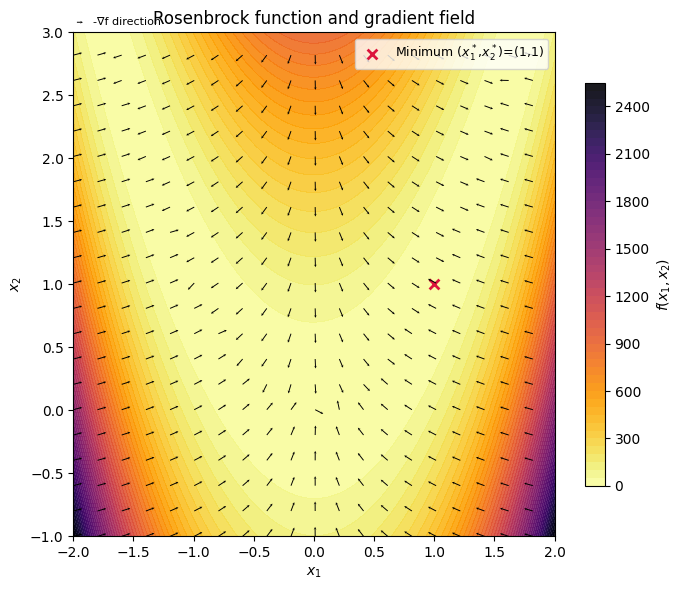

In [13]:
x1 = np.linspace(-2, 2, 200)
x2 = np.linspace(-1, 3, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = rosenbrock((X1, X2))

fig, ax = plt.subplots(figsize=(7,6))

# Contour plot
contours = ax.contourf(X1, X2, Z, levels=60, cmap=cm.inferno_r, alpha=0.9)
cbar = fig.colorbar(contours, ax=ax, shrink=0.8, label='$f(x_1, x_2)$')

ax.set_title("Rosenbrock function and gradient field", fontsize=12)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

# Punt mínim
ax.scatter(1, 1, color='crimson', s=50, marker='x', lw=2,
           label="Minimum ($x_1^*$,$x_2^*$)=(1,1)")

# --- Camp de gradients ---
step = 10
Xg = X1[::step, ::step]
Yg = X2[::step, ::step]

U = np.zeros_like(Xg)
V = np.zeros_like(Yg)
for i in range(Xg.shape[0]):
    for j in range(Xg.shape[1]):
        gx, gy = rosenbrock_grad((Xg[i, j], Yg[i, j]))
        U[i, j] = gx
        V[i, j] = gy

# Normalitzem per mostrar direcció
norm = np.hypot(U, V)
eps = 1e-12
U_dir = U / (norm + eps)
V_dir = V / (norm + eps)

length = 1.5
q = ax.quiver(
    Xg, Yg, -U_dir*length, -V_dir*length,  # negatiu → direcció de descens
    color='black', angles='xy', scale_units='xy', scale=20,
    width=0.002, headwidth=3, headlength=3, headaxislength=2, minlength=0.4
)
ax.quiverkey(q, X=0.02, Y=1.02, U=1, label='-∇f direction',
             labelpos='E', coordinates='axes', fontproperties={'size': 8})

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()



From the contour plot with the gradient information, we can observe that the gradient vectors do not point directly towards the minimum at $(1, 1)$.  
Instead, they tend to point towards the curved valley of the function, approximately along the line $y = x^2$.  
This happens because the gradient has a much stronger component driving the descent toward the valley than along it.  
Once the algorithm reaches this narrow valley, the gradient magnitude in the direction of the minimum becomes much smaller, so the updates become slower and the trajectory gradually follows the valley until it finally converges to $(1, 1)$.


In [14]:
def gradient_descent_rosenbrock_adapt(x0, alpha=0.01, tol_grad=1e-05, tol_x=1e-05, max_backtracks=5):
    x = np.array(x0, dtype=float)
    path = [x.copy()]
    criteria = True
    k=0

    while criteria:
        g = rosenbrock_grad(x)
        y = x - alpha * g
        beta=alpha

        div_lim = 0
        while f2(y)>f2(x):
            beta = beta/2
            y = x-(beta)*g
            div_lim += 1
            if div_lim >= max_backtracks:
                # print("Maximum backtracks reached for initial point:", x0)
                break    


        if np.linalg.norm(x-y)<tol_x or np.linalg.norm(rosenbrock_grad(y))<tol_grad:
            criteria = False
        x=y
        k+=1
        path.append(x.copy())
    return np.array(path), k #, alpha


In [15]:
initial_points = [np.array([-0.5, 0.8]),
                  np.array([-1,2]),
                  np.array([1.5, 0]),
                  np.array([0, 2]),
                  np.array([0.7, 0.5]),
                  np.array([-1.3, 0]),
                  ]

STOPPING CRITERIA: tol_grad=1e-5, tol_x=1e-3
Starting point: [-0.5  0.8]  ||  Final point: [-0.74985845  0.57558083]  ||  iterations: 23,  ||  distance to minimum: 1.80e+00
Starting point: [-1  2]  ||  Final point: [-0.64231328  0.42649226]  ||  iterations: 205,  ||  distance to minimum: 1.74e+00
Starting point: [1.5 0. ]  ||  Final point: [-0.60555036  0.38118241]  ||  iterations: 138,  ||  distance to minimum: 1.72e+00
Starting point: [0 2]  ||  Final point: [0.51073964 0.26674496]  ||  iterations: 41,  ||  distance to minimum: 8.81e-01
Starting point: [0.7 0.5]  ||  Final point: [0.70266737 0.49849699]  ||  iterations: 3,  ||  distance to minimum: 5.83e-01
Starting point: [-1.3  0. ]  ||  Final point: [0.91525109 0.84144573]  ||  iterations: 6,  ||  distance to minimum: 1.80e-01


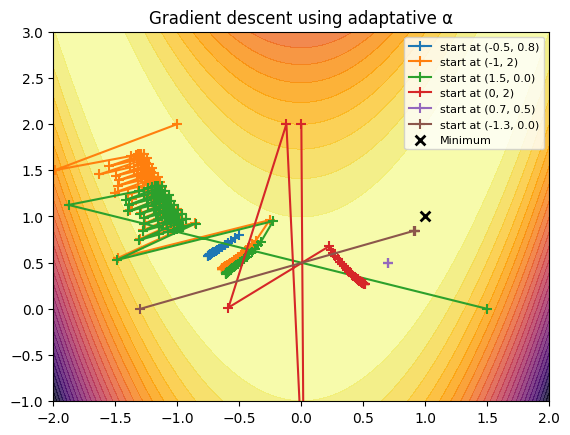

In [16]:
x1 = np.linspace(-2, 2, 200)
x2 = np.linspace(-1, 3, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = rosenbrock((X1, X2))

print("STOPPING CRITERIA: tol_grad=1e-5, tol_x=1e-3")

plt.contourf(X1, X2, Z, levels=30, cmap=cm.inferno_r, alpha=0.8)

for x0 in initial_points:
    path, k = gradient_descent_rosenbrock_adapt(x0, alpha=0.01, tol_grad=1e-05, tol_x=1e-03)
    plt.plot(path[:,0], path[:,1], marker="+", markersize=7, markeredgewidth=1.5, label=f"start at ({x0[0]}, {x0[1]})")
    print(f"Starting point: {x0}  ||  Final point: {path[-1]}  ||  iterations: {k},  ||  distance to minimum: {np.linalg.norm(path[-1]-np.array([1,1])):.2e}")

plt.scatter(1, 1, color='black', s=50, marker='x', lw=2,
           label="Minimum")
plt.legend(fontsize=8)
plt.title("Gradient descent using adaptative α")
plt.ylim(-1, 3)
plt.show()


When running the backtracking gradient descent on the Rosenbrock function without limiting the number of iterations, and keeping the same stopping criteria, we obtain the results above.

We can observe that, depending on the starting point, the algorithm performs between approximately $10^0$ and $10^2$ iterations.  
However, if we look at the final points, they generally do not get close to the true minimum $(1, 1)$.  
**The algorithm stops prematurely because, inside the valley of the Rosenbrock function and near the minimum, the function values change very little between iterations.**  
As a result, the stopping criterion (concretely the one based on the small difference in $|f(\mathbf{x}_{k+1}) - f(\mathbf{x}_k)|$) is satisfied before the algorithm actually reaches the minimum.

STOPPING CRITERIA: tol_grad=1e-5, tol_x=1e-5
Starting point: [-0.5  0.8]  ||  Final point: [0.96522245 0.93151227]  ||  iterations: 18410,  ||  distance to minimum: 7.68e-02
Starting point: [-1  2]  ||  Final point: [0.96522287 0.93151309]  ||  iterations: 18294,  ||  distance to minimum: 7.68e-02
Starting point: [1.5 0. ]  ||  Final point: [0.96521994 0.93150742]  ||  iterations: 18134,  ||  distance to minimum: 7.68e-02
Starting point: [0 2]  ||  Final point: [0.96522107 0.9315096 ]  ||  iterations: 16140,  ||  distance to minimum: 7.68e-02
Starting point: [0.7 0.5]  ||  Final point: [0.9652236  0.93151449]  ||  iterations: 14068,  ||  distance to minimum: 7.68e-02
Starting point: [-1.3  0. ]  ||  Final point: [0.96522107 0.93150961]  ||  iterations: 6378,  ||  distance to minimum: 7.68e-02


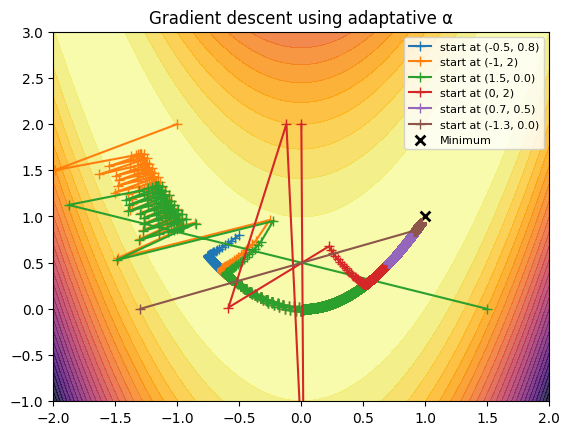

In [17]:
print("STOPPING CRITERIA: tol_grad=1e-5, tol_x=1e-5")

plt.contourf(X1, X2, Z, levels=30, cmap=cm.inferno_r, alpha=0.8)

for x0 in initial_points:
    path, k = gradient_descent_rosenbrock_adapt(x0, alpha=0.01, tol_grad=1e-05, tol_x=1e-05)
    plt.plot(path[:,0], path[:,1], marker="+", markersize=7, markeredgewidth=1, label=f"start at ({x0[0]}, {x0[1]})")
    print(f"Starting point: {x0}  ||  Final point: {path[-1]}  ||  iterations: {k},  ||  distance to minimum: {np.linalg.norm(path[-1]-np.array([1,1])):.2e}")

plt.scatter(1, 1, color='black', s=50, marker='x', lw=2,
           label="Minimum")
plt.legend(fontsize=8)
plt.title("Gradient descent using adaptative α")
plt.ylim(-1, 3)
plt.show()

STOPPING CRITERIA: tol_grad=1e-5, tol_x=1e-7
Starting point: [-0.5  0.8]  ||  Final point: [0.99964239 0.99928348]  ||  iterations: 54648,  ||  distance to minimum: 8.01e-04
Starting point: [-1  2]  ||  Final point: [0.9996424  0.99928349]  ||  iterations: 54532,  ||  distance to minimum: 8.01e-04
Starting point: [1.5 0. ]  ||  Final point: [0.99964241 0.99928352]  ||  iterations: 54373,  ||  distance to minimum: 8.01e-04
Starting point: [0 2]  ||  Final point: [0.99964238 0.99928345]  ||  iterations: 52378,  ||  distance to minimum: 8.01e-04
Starting point: [0.7 0.5]  ||  Final point: [0.9996424 0.9992835]  ||  iterations: 50306,  ||  distance to minimum: 8.01e-04
Starting point: [-1.3  0. ]  ||  Final point: [0.99964238 0.99928345]  ||  iterations: 42616,  ||  distance to minimum: 8.01e-04


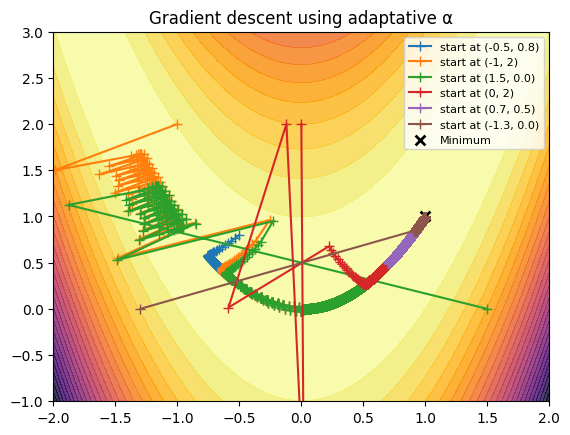

In [18]:
print("STOPPING CRITERIA: tol_grad=1e-5, tol_x=1e-7")

plt.contourf(X1, X2, Z, levels=30, cmap=cm.inferno_r, alpha=0.8)

for x0 in initial_points:
    path, k = gradient_descent_rosenbrock_adapt(x0, alpha=0.01, tol_grad=1e-05, tol_x=1e-07)
    plt.plot(path[:,0], path[:,1], marker="+", markersize=7, markeredgewidth=1, label=f"start at ({x0[0]}, {x0[1]})")
    print(f"Starting point: {x0}  ||  Final point: {path[-1]}  ||  iterations: {k},  ||  distance to minimum: {np.linalg.norm(path[-1]-np.array([1,1])):.2e}")

plt.scatter(1, 1, color='black', s=50, marker='x', lw=2,
           label="Minimum")
plt.legend(fontsize=8)
plt.title("Gradient descent using adaptative α")
plt.ylim(-1, 3)
plt.show()

STOPPING CRITERIA: tol_grad=1e-5, tol_x=1e-10
Starting point: [-0.5  0.8]  ||  Final point: [0.99998882 0.9999776 ]  ||  iterations: 82409,  ||  distance to minimum: 2.50e-05
Starting point: [-1  2]  ||  Final point: [0.99998882 0.9999776 ]  ||  iterations: 82293,  ||  distance to minimum: 2.50e-05
Starting point: [1.5 0. ]  ||  Final point: [0.99998882 0.9999776 ]  ||  iterations: 82134,  ||  distance to minimum: 2.50e-05
Starting point: [0 2]  ||  Final point: [0.99998882 0.9999776 ]  ||  iterations: 80139,  ||  distance to minimum: 2.50e-05
Starting point: [0.7 0.5]  ||  Final point: [0.99998882 0.9999776 ]  ||  iterations: 78067,  ||  distance to minimum: 2.50e-05
Starting point: [-1.3  0. ]  ||  Final point: [0.99998882 0.9999776 ]  ||  iterations: 70377,  ||  distance to minimum: 2.50e-05


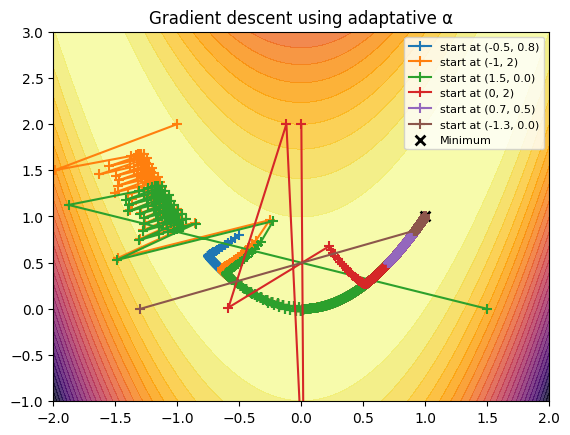

In [19]:
print("STOPPING CRITERIA: tol_grad=1e-5, tol_x=1e-10")

plt.contourf(X1, X2, Z, levels=30, cmap=cm.inferno_r, alpha=0.8)

for x0 in initial_points:
    path, k = gradient_descent_rosenbrock_adapt(x0, alpha=0.01, tol_grad=1e-05, tol_x=1e-10)
    plt.plot(path[:,0], path[:,1], marker="+", markersize=7, markeredgewidth=1.5, label=f"start at ({x0[0]}, {x0[1]})")
    print(f"Starting point: {x0}  ||  Final point: {path[-1]}  ||  iterations: {k},  ||  distance to minimum: {np.linalg.norm(path[-1]-np.array([1,1])):.2e}")

plt.scatter(1, 1, color='black', s=50, marker='x', lw=2,
           label="Minimum")
plt.legend(fontsize=8)
plt.title("Gradient descent using adaptative α")
plt.ylim(-1, 3)
plt.show()

<div style="border: 2px solid white; padding: 10px; border-radius: 10px;">


**Solution**

By making the stopping criterion more demanding, we can see that the algorithm converges closer to the true minimum of the Rosenbrock function.  
However, this improvement in accuracy comes at the cost of a larger number of iterations, now up to the order of $10^5$, depending on the threshold and the starting point.

In particular, when setting $|f(\mathbf{x}_{k+1}) - f(\mathbf{x}_k)| < 10^{-10}$, the algorithm achieves a precision of approximately $10^{-5}$ in terms of the distance to the minimum.
This confirms that, in such a narrow valley where the function values vary very little near the optimum, a stricter stopping criterion is essential to ensure convergence to points very close to the global minimum $(\mathbf{x}_{1}^*, \mathbf{x}_{2}^*)=(1, 1)$, although it significantly increases the computational cost.

## ***2. Newton descent method***

### ***2.1. A simple quadratic function***

Let us consider a simple quadratic function $$\boxed{f(x) = 100x_1^2+x_2^2}$$

In [9]:
def grad_f(x):
    return np.array([200*x[0],2*x[1]])

def f(x):
    return (100*x[0])**2+(x[1])**2

def gradient_descent(x0, alpha=0.1):
    x = x0
    path = [x]
    criteria = True
    k=0
    while criteria:
        y = x - alpha * grad_f(x)
        
        while f(y)>=f(x): 
            alpha = alpha/2
            y = x-(alpha)*grad_f(x)
                      
        if np.linalg.norm(x-y)<1e-03 or np.linalg.norm(grad_f(y))<1e-05:
            criteria = False
        x=y
        k+=1
        path.append(y)
        
    return(np.array(path), y, k)

##### **Solving the Newton direction algorithm**

***Before implementing the Newton direction algorithm, we must solve the following equations.***

In this case, the Hessian of $f$ is a constant. Thus, the Newton direction can be easily calculated:

$$
\nabla^2 f(\mathbf{x}) = 
\begin{bmatrix}
200 & 0 \\
0 & 2
\end{bmatrix}
$$
$$
\nabla^2 f(\mathbf{x}^k)\mathbf{d}^k = -\nabla f(\mathbf{x}^k) \Longleftrightarrow 
\begin{cases}
200\mathbf{d_1} = -\frac{\partial f}{\partial x_1} = -200\mathbf{x_1}\\
2\mathbf{d_2} = -\frac{\partial f}{\partial x_2} = -2\mathbf{x_2}
\end{cases}
\Longleftrightarrow 
\begin{cases}
\mathbf{d_1} = -\mathbf{x_1}\\
\mathbf{d_2} = -\mathbf{x_2} 
\end{cases}
$$

**We observe that the Newton directions are always pointing at the origin ($\mathbf{d}=-\mathbf{x}$), no matter the step in which we are.** This is a very good property, since the minimum is located precisly at the origin. 

Indeed, at a point $\mathbf{x^k}$ the new iteration will be: $$\mathbf{x^{k+1}} = \mathbf{x^k} + \alpha^k \mathbf{d^k} = \mathbf{x^k} - \alpha^k \mathbf{x^k} = (1-\alpha^k)\mathbf{x^k}$$

In [10]:
def newton_descent(x0, alpha=0.1):
    x = x0
    path = [x]
    criteria = True
    k=0
    while criteria:
        y = (1-alpha) * x #Newton direction
        while f(y)>=f(x): 
            alpha = alpha/2
            y = (1-alpha) * x             
        if np.linalg.norm(x-y)<1e-03 or np.linalg.norm(grad_f(y))<1e-05:
            criteria = False
        x=y
        k+=1
        
        path.append(y)
        
    return(np.array(path), y, k)

In [11]:
path_1, y_1, k_1 = gradient_descent(np.array([1,1]))
path_2, y_2, k_2 = newton_descent(np.array([1,1]))

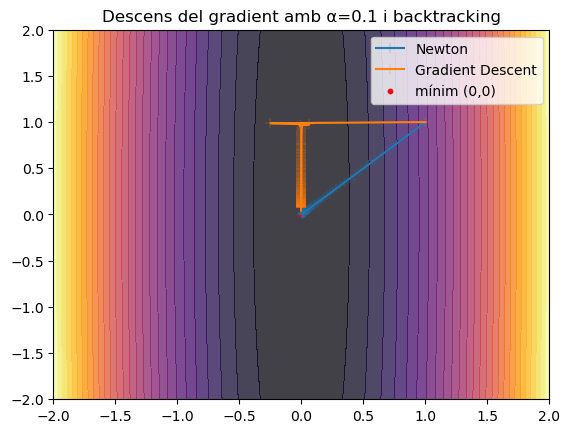

NUMBER OF ITERATIONS: 
 Newton: 48 
 Gradient Descent: 202


In [12]:
x1 = np.linspace(-2, 2, 400)
x2 = np.linspace(-2, 2, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = 100*X1**2 + X2**2

plt.contourf(X1, X2, Z, levels=30, cmap="inferno", alpha=0.75)
plt.plot(path_2[:,0], path_2[:,1], marker="+", markersize=7, markeredgewidth=0.2, label=f"Newton")
plt.plot(path_1[:,0], path_1[:,1], marker="+", markersize=7, markeredgewidth=0.2, label=f"Gradient Descent")

plt.scatter(0,0,color="red",s=10,label="mínim (0,0)")
plt.legend()
plt.title("Descens del gradient amb α=0.1 i backtracking")
plt.show()

print(f'NUMBER OF ITERATIONS: \n Newton: {k_2} \n Gradient Descent: {k_1}')

As we expected, the Newton direction algorithm converges faster. 

### ***2.2. A function with multiple minima***

Case of study: 
$$\boxed{f(x_1,x_2) = x_1^2(4 - 2.1x_1^2 + \frac{1}{3}x_1^4) + x_1x_2 + x_2^2(-4 + 4x_2^2)}$$

Let us calculate the **partial derivatives** in order to find the gradient $\nabla f = \left(\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}\right)^T$:

$$
\begin{cases}
\dfrac{\partial f}{\partial x_{1}} 
= 2x_{1}\!\left(4 - 2.1x_{1}^{2} + \tfrac{1}{3}x_{1}^{4}\right) 
+ x_{1}^{2}\!\left(-4.2x_{1} + \tfrac{4}{3}x_{1}^{3}\right) + x_{2}
\dfrac{\partial f}{\partial x_{2}} 
= x_{1} + 2x_{2}\!\left(-4 + 4x_{2}^{2}\right) + x_{2}^{2}(8x_{2})
\end{cases}
$$

let us calculate the **second order derivatives**. For the mixed partial derivatives, one can easily see that $$ \dfrac{\partial^2 f}{\partial x_1\partial x_2}= \dfrac{\partial^2 f}{\partial x_2\partial x_1} = 1. $$

And:

$$
\dfrac{\partial^2 f}{\partial x_1^2} = 2(4 - 2.1x_{1}^{2} + \tfrac{1}{3}x_{1}^{4})
+ 2x_{1}\!\left(-4.2x_{1} + \tfrac{4}{3}x_{1}^{3}\right)
+ x_{1}^{2}\!\left(-4.2 + 4x_{1}^{2}\right)$$

$$\dfrac{\partial^2 f}{\partial x_2^2} =  -8 + 48x_{2}^{2}$$

Therefore, the Hessian matrix at a point $(x_1,x_2)$ is the following:

$$
H_f(x_1,x_2) =
\begin{pmatrix}
\dfrac{\partial^2 f}{\partial x_1^2} & \dfrac{\partial^2 f}{\partial x_1\partial x_2} \\[8pt]
\dfrac{\partial^2 f}{\partial x_2\partial x_1} & \dfrac{\partial^2 f}{\partial x_2^2}
\end{pmatrix}
=
\begin{pmatrix}
2\!\left(4 - 2.1x_{1}^{2} + \tfrac{1}{3}x_{1}^{4}\right)
+ 2x_{1}\!\left(-4.2x_{1} + \tfrac{4}{3}x_{1}^{3}\right)
+ x_{1}^{2}\!\left(-4.2 + 4x_{1}^{2}\right)
& 1 \\[10pt]
1 & -8 + 48x_{2}^{2}
\end{pmatrix}.
$$


We will be forced to solve the system $H(x)\mathbf{d} = \nabla{f}(\mathbf{x})$. Let us define $a$ and $b$:

$$a(\mathbf{x}) = 2\!\left(4 - 2.1x_{1}^{2} + \tfrac{1}{3}x_{1}^{4}\right)
+ 2x_{1}\!\left(-4.2x_{1} + \tfrac{4}{3}x_{1}^{3}\right)
+ x_{1}^{2}\!\left(-4.2 + 4x_{1}^{2}\right)$$

$$b(\mathbf{x}) = -8 + 48x_{2}^{2}$$

Assuming $H(\mathbf{x})$ is a non-singular matrix, with $Det(H(x)) = 1-a(\mathbf{x})b(\mathbf{b}) \neq 0$, we can write: 

$$ H(\mathbf{x})^{-1} = \frac{1}{Det(H(\mathbf{x}))} \begin{pmatrix}
b(x)
& -1 \\[10pt]
-1 & a(x)
\end{pmatrix} \Longrightarrow \mathbf{d} = \frac{1}{Det(H(\mathbf{x}))} \begin{pmatrix}
b(x)
& -1 \\[10pt]
-1 & a(x)
\end{pmatrix} \nabla{f}(\mathbf{x})$$

<div style="border: 2px solid white; padding: 10px; border-radius: 10px;">
    
### ***``PROBLEM!``*** 
One must notice that the Newton direction is **`not always a descent direction`**. In fact, it will be a descent direction at one point if, and only if, the Hessian is positive definite at that point. 

$\Longrightarrow$ Therefore, the algorithm cannot be initiallized at a point with a non-positive definite matrix. 

Recall the alpha-adaptive algorithm we have been using in gradient descent. Here we first set the descent direction at a point $x^k$ and then check whether $f(x^k)>f(x^{k+1})$. If this condition is not satisfied, then we reduce $\alpha$ iteratively until we obtain a descent. 

In gradient descent, it is guaranteed that for a small enough $\alpha$ we will get a descent, as small as it may be. This is not the case for the Newton direction, which will get stuck reducing the value of $\alpha$ until it equals $0$. As a consequence, it will trivially converge when $\alpha$ 
is close enough to $0$ with the criteria  $||x^k-x^{k+1}||<1e-3$ satisfied. 

In conclusion, either we find a path of points with positive definite matrices or we remove the $\alpha$-adaptative feature. 

In [13]:
def gradient_f2(x):
    df_dx1 = (2*x[0]*(4 - 2.1*x[0]**2 + (1/3)*x[0]**4) + 
              x[0]**2*(-4.2*x[0] + (4/3)*x[0]**3) + x[1])
    
    df_dx2 = x[0] + 2*x[1]*(-4 + 4*x[1]**2) + 8*x[1]**3
    
    return np.array([df_dx1, df_dx2])

def f2(x):
    return (x[0]**2 * (4 - 2.1*x[0]**2 + (1/3)*x[0]**4) + 
            x[0]*x[1] + 
            x[1]**2 * (-4 + 4*x[1]**2))

def compute_H_and_G(x): #Hessian matrix
    x1, x2 = float(x[0]), float(x[1])
    # a = H[0,0]
    a = (2 * (4 - 2.1*x1**2 + (1/3)*x1**4)
         + 2*x1 * (-4.2*x1 + (4/3)*x1**3)
         + x1**2 * (-4.2 + 4*x1**2))
    b = -8 + 48 * x2**2  # H[1,1]
    g1 = (2*x1 * (4 - 2.1*x1**2 + (1/3)*x1**4)
          + x1**2 * (-4.2*x1 + (4/3)*x1**3)
          + x2)
    g2 = x1 + 2*x2 * (-4 + 4*x2**2) + x2**2 * (8*x2)
    H = np.array([[a, 1.0],
                  [1.0, b]], dtype=float)
    G = np.array([g1, g2], dtype=float)
    return H, G

def solve_Newton_f2(x):
    H, G = compute_H_and_G(x)
    a = H[0,0]; b = H[1,1]
    g1, g2 = G[0], G[1]
    delta = a*b - H[1,0]*H[0,1]
    if abs(delta) < 1e-12:
        raise np.linalg.LinAlgError("Singular or nearly singular (delta ~ 0).")
    d1 = (b*g1 - g2) / delta
    d2 = (-g1 + a*g2) / delta
    return np.array([d1, d2])

def gradient_descent2(x0, alpha=0.01):
    x = x0
    path = [x]
    criteria = True
    k=0
    while criteria:
        y = x - alpha * gradient_f2(x)
        
        while f2(y)>=f2(x): 
            alpha = alpha/2
            y = x-(alpha)*gradient_f2(x)
                      
        if np.linalg.norm(x-y)<1e-03 or np.linalg.norm(gradient_f2(y))<1e-05:
            criteria = False
        x=y
        k+=1
        path.append(y)
    return (np.array(path), y, k)

def Newton_descent2(x0, alpha=0.5):
    x = x0
    path = [x]
    criteria = True
    k=0
    while criteria:
        dir = solve_Newton_f2(x)
        y = x - alpha * dir
        while f2(y)>=f2(x): 
            print(y,alpha)
            alpha = alpha/2
            y = x-(alpha)*dir
        
        if np.linalg.norm(x-y)<1e-03 or np.linalg.norm(gradient_f2(y))<1e-05:
            criteria = False
        x=y
        k+=1
        path.append(y)
    return (np.array(path), y, k)

    
path_3, y_3, k_3 = gradient_descent2(np.array([-2,-1]))
path_4, y_4, k_4 = Newton_descent2(np.array([-2,-1]))
path_5, y_5, k_5 = gradient_descent2(np.array([2,-0.5]))
path_6, y_6, k_6 = Newton_descent2(np.array([2,-0.5]))
print(f'GRADIENT DESCENT FROM (-2,-1): {k_3} CONVERGES TO: {y_3}')
print(f'NEWTON DESCENT FROM (-2,-1): {k_4} CONVERGES TO: {y_4}')
print(f'GRADIENT DESCENT FROM (2,-0.5): {k_5} CONVERGES TO: {y_5}')
print(f'NEWTON DESCENT FROM (2,-0.5): {k_6} CONVERGES TO: {y_6}')

GRADIENT DESCENT FROM (-2,-1): 33 CONVERGES TO: [-1.6087467  -0.57889655]
NEWTON DESCENT FROM (-2,-1): 13 CONVERGES TO: [-1.6088467  -0.56874074]
GRADIENT DESCENT FROM (2,-0.5): 21 CONVERGES TO: [ 1.70423806 -0.79326857]
NEWTON DESCENT FROM (2,-0.5): 11 CONVERGES TO: [ 1.70430897 -0.79640228]


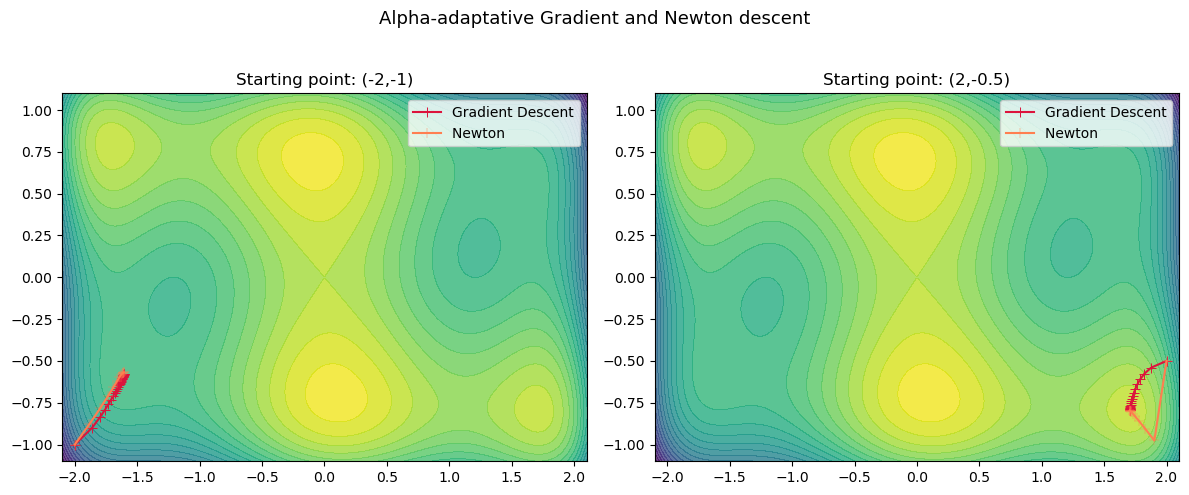

In [14]:
def f(x1, x2):
    return (x1**2 * (4 - 2.1*x1**2 + (1/3)*x1**4) + 
            x1*x2 + 
            x2**2 * (-4 + 4*x2**2))


x1 = np.linspace(-2.1, 2.1, 400)
x2 = np.linspace(-1.1, 1.1, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = f(X1, X2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# === Subfigure 1: paths 3 & 4 ===
ax = axes[0]
ax.contourf(X1, X2, Z, levels=30, cmap=cm.viridis_r, alpha=0.8)
ax.plot(path_3[:,0], path_3[:,1], marker="+", color='crimson', markersize=7, markeredgewidth=0.7, label="Gradient Descent")
ax.plot(path_4[:,0], path_4[:,1], marker="+", color = 'coral', markersize=7, markeredgewidth=0.3, label="Newton ")

ax.legend()
ax.set_title("Starting point: (-2,-1)")

# === Subfigure 2: paths 5 & 6 ===
ax = axes[1]
ax.contourf(X1, X2, Z, levels=30, cmap=cm.viridis_r, alpha=0.8)
ax.plot(path_5[:,0], path_5[:,1], marker="+", markersize=7, color='crimson', markeredgewidth=0.7, label="Gradient Descent")
ax.plot(path_6[:,0], path_6[:,1], marker="+", markersize=7, color='coral', markeredgewidth=0.3, label="Newton ")
ax.legend()
ax.set_title("Starting point: (2,-0.5)")

# === Global figure adjustments ===
fig.suptitle('Alpha-adaptative Gradient and Newton descent', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Starting from point $(-2,-1)$ both methods achieve the solution but with a very different number of iterations. While the Gradient method needs 33 iterations, the Newton method only needs 13, **less than a half**. The same goes for the algorithms starting from point $(2, -0.5)$. 


**We can see in the graphic above that the Newton methods is able to catch "smarter directions" than de Gradient.**

***Since the Newton direction is not always a descent direction, let us combine gradient and Newton descent***

In [15]:
def is_positive_definite(A, tol=1e-12):
    eigvals = np.linalg.eigvalsh(A) 
    return np.all(eigvals > tol)

def combined_descent(x0, alpha=0.5):
    x = x0
    path = [x]
    criteria = True
    k=0
    while criteria:
        H,G = compute_H_and_G(x)
        if is_positive_definite(H):
            dir = solve_Newton_f2(x)
            y = x - alpha * dir
        else:
            y = x - alpha * gradient_f2(x)
        beta=alpha   
        while f2(y)>=f2(x): 
            beta = beta/2
            if is_positive_definite(H):
                dir = solve_Newton_f2(x)
                y = x - beta * dir
            else:
                y = x - beta * gradient_f2(x)
                          
        if np.linalg.norm(x-y)<1e-03 or np.linalg.norm(gradient_f2(y))<1e-05:
            criteria = False
        x=y
        k+=1
        path.append(y)
    return (np.array(path), y, k)

path_7, y_7,k_7 = combined_descent(np.array([1,1]))
path_8, y_8,k_8 = combined_descent(np.array([2,-0.5]))
path_9, y_9,k_9 = combined_descent(np.array([-2,-1]))
path_11, y_11,k_11 = combined_descent(np.array([0.5,0]))


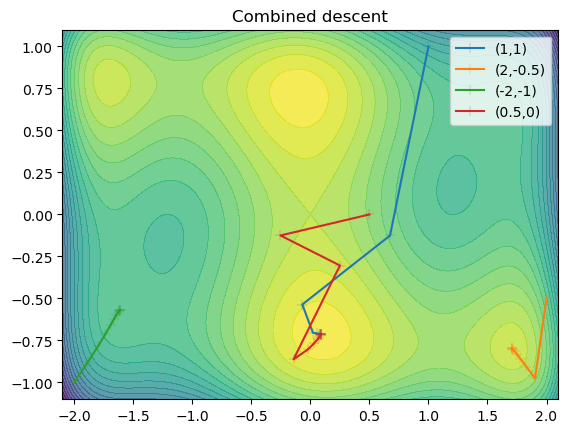

In [16]:
plt.contourf(X1, X2, Z, levels=30, cmap=cm.viridis_r, alpha=0.75)
plt.plot(path_7[:,0], path_7[:,1], marker="+", markersize=7, markeredgewidth=0.2, label=f"(1,1)")
plt.plot(path_8[:,0], path_8[:,1], marker="+", markersize=7, markeredgewidth=0.2, label=f"(2,-0.5)")
plt.plot(path_9[:,0], path_9[:,1], marker="+", markersize=7, markeredgewidth=0.2, label=f"(-2,-1)")
plt.plot(path_11[:,0], path_11[:,1], marker="+", markersize=7, markeredgewidth=0.2, label=f"(0.5,0)")



plt.legend()
plt.title("Combined descent")
plt.show()


In [17]:
k_7, k_8, k_9, k_11

(10, 11, 13, 12)

**Conclusion**

As we suspected, the combined method **reduces the number of iterations** needed to reach the solution. Furthermore, it allows us to choose **any starting point** since it does not require the positive definite condition.   

### ***2.3. The Rosenbruck function***

$$
f(x,y) = (1 - x)^2 + 100 (y - x^2)^2
$$

**Gradient:**

$$
\nabla f(x,y) =
\begin{pmatrix}
\frac{\partial f}{\partial x} \\
\frac{\partial f}{\partial y}
\end{pmatrix}
=
\begin{pmatrix}
2(x - 1) - 400x(y - x^2) \\
200 (y - x^2)
\end{pmatrix}
$$

**Hessian:**

$$
\nabla^2 f(x,y) =
\begin{pmatrix}
\frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\
\frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2}
\end{pmatrix}
=
\begin{pmatrix}
2 - 400y + 1200x^2 & -400x \\
-400x & 200
\end{pmatrix}
$$


In [18]:
def rosenbrock(x):
    x1, x2 = x
    return (1 - x1)**2 + 100 * (x2 - x1**2)**2

def rosenbrock_diff(x): 
    #GRADIENT
    x1, x2 = x
    dfdx1 = 2 * (x1 - 1) - 400 * x1 * (x2 - x1**2)
    dfdx2 = 200 * (x2 - x1**2)
    G = np.array([dfdx1, dfdx2])
    #HESSIAN
    h11 = 2 - 400 * x2 + 1200 * x1**2
    h12 = -400 * x1
    h21 = -400 * x1
    h22 = 200
    H = np.array([[h11, h12],
                     [h21, h22]])
    return H,G

    


In [19]:
def solve_Newton_f3(x):
    H, G = rosenbrock_diff(x)
    a = H[0,0]; b = H[1,1]
    g1, g2 = G[0], G[1]
    delta = a*b - H[1,0]*H[0,1]
    if abs(delta) < 1e-12:
        raise np.linalg.LinAlgError("Singular or nearly singular (delta ~ 0).")
    d1 = (-b*g1 + H[0,1]*g2) / delta
    d2 = (+H[1,0]*g1 - a*g2) / delta
    return np.array([d1, d2])



def combined_descentR(x0, alpha=0.01):
    x = x0
    path = [x]
    criteria = True
    k=0
    direction_used = []  # store "Newton" or "Gradient"

    while criteria:
        H,G = rosenbrock_diff(x)
        if is_positive_definite(H):
            dir = solve_Newton_f3(x)
            y = x + alpha * dir
            direction_used.append("Newton")

        else:
            y = x - alpha * G
            direction_used.append("Gradient")

        inner_iter = 0   
        beta=alpha
        while rosenbrock(y)>rosenbrock(x) and inner_iter<5: 
            beta=beta/2
            inner_iter += 1
            
            if is_positive_definite(H):
                dir = solve_Newton_f3(x)
                y = x + beta * dir
            else:
                y = x - beta * G
                
        H, G = rosenbrock_diff(y)                  
        if np.linalg.norm(x-y)<1e-10 or np.linalg.norm(G)<1e-05:
            criteria = False
        x=y
        k+=1
        path.append(y)
    return (np.array(path), np.array(direction_used), y, k)

Starting point: [-0.5  0.8]  ||  Final point: [0.99999252 0.999985  ]  ||  iterations: 1544,  ||  distance to minimum: 1.68e-05
Starting point: [-1  2]  ||  Final point: [0.9999923  0.99998455]  ||  iterations: 1799,  ||  distance to minimum: 1.73e-05
Starting point: [1.5 0. ]  ||  Final point: [1.00000146 1.00000291]  ||  iterations: 1881,  ||  distance to minimum: 3.26e-06
Starting point: [0 2]  ||  Final point: [0.99999121 0.99998237]  ||  iterations: 1224,  ||  distance to minimum: 1.97e-05
Starting point: [0.7 0.5]  ||  Final point: [0.99999699 0.99999394]  ||  iterations: 1234,  ||  distance to minimum: 6.77e-06
Starting point: [-1.3  0. ]  ||  Final point: [0.99999236 0.99998467]  ||  iterations: 1904,  ||  distance to minimum: 1.71e-05


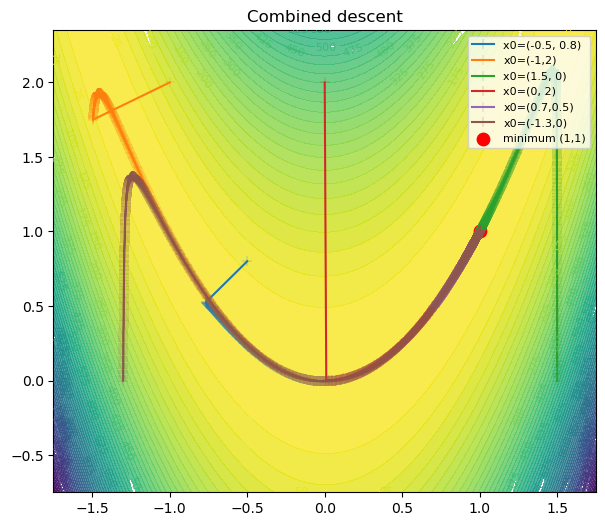

In [22]:
initial_points = [np.array([-0.5, 0.8]),
                  np.array([-1,2]),
                  np.array([1.5, 0]),
                  np.array([0, 2]),
                  np.array([0.7, 0.5]),
                  np.array([-1.3, 0]),
                  ]

path_13, directions_13, y_13,k_13 = combined_descentR(initial_points[0])
print(f"Starting point: {initial_points[0]}  ||  Final point: {path_13[-1]}  ||  iterations: {k_13},  ||  distance to minimum: {np.linalg.norm(path_13[-1]-np.array([1,1])):.2e}")

path_14, directions_14, y_14,k_14 = combined_descentR(initial_points[1])
print(f"Starting point: {initial_points[1]}  ||  Final point: {path_14[-1]}  ||  iterations: {k_14},  ||  distance to minimum: {np.linalg.norm(path_14[-1]-np.array([1,1])):.2e}")

path_15, directions_15, y_15,k_15 = combined_descentR(initial_points[2])
print(f"Starting point: {initial_points[2]}  ||  Final point: {path_15[-1]}  ||  iterations: {k_15},  ||  distance to minimum: {np.linalg.norm(path_15[-1]-np.array([1,1])):.2e}")

path_16, directions_16, y_16,k_16 = combined_descentR(initial_points[3])
print(f"Starting point: {initial_points[3]}  ||  Final point: {path_16[-1]}  ||  iterations: {k_16},  ||  distance to minimum: {np.linalg.norm(path_16[-1]-np.array([1,1])):.2e}")

path_17, directions_17, y_17,k_17 = combined_descentR(initial_points[4])
print(f"Starting point: {initial_points[4]}  ||  Final point: {path_17[-1]}  ||  iterations: {k_17},  ||  distance to minimum: {np.linalg.norm(path_17[-1]-np.array([1,1])):.2e}")

path_18, directions_18, y_18,k_18 = combined_descentR(initial_points[5])
print(f"Starting point: {initial_points[5]}  ||  Final point: {path_18[-1]}  ||  iterations: {k_18},  ||  distance to minimum: {np.linalg.norm(path_18[-1]-np.array([1,1])):.2e}")


x = np.linspace(-1.75, 1.75, 400)
y = np.linspace(-0.75, 2.35, 400)
X, Y = np.meshgrid(x, y)
Z = rosenbrock(np.array([X, Y]))

# Plot contour lines
plt.figure(figsize=(7, 6))
contours = plt.contourf(X, Y, Z, levels=70, cmap=cm.viridis_r, alpha=0.8)
plt.clabel(contours, inline=True, fontsize=8)

plt.plot(path_13[:,0], path_13[:,1], marker="+", markersize=7, markeredgewidth=0.2, label=f"x0=(-0.5, 0.8)")
plt.plot(path_14[:,0], path_14[:,1], marker="+", markersize=7, markeredgewidth=0.2, label=f"x0=(-1,2)")
plt.plot(path_15[:,0], path_15[:,1], marker="+", markersize=7, markeredgewidth=0.2, label=f"x0=(1.5, 0)")
plt.plot(path_16[:,0], path_16[:,1], marker="+", markersize=7, markeredgewidth=0.2, label=f"x0=(0, 2)")
plt.plot(path_17[:,0], path_17[:,1], marker="+", markersize=7, markeredgewidth=0.2, label=f"x0=(0.7,0.5)")
plt.plot(path_18[:,0], path_18[:,1], marker="+", markersize=7, markeredgewidth=0.2, label=f"x0=(-1.3,0)")


plt.scatter(1,1,color="red",s=80,label="minimum (1,1)")
plt.legend(loc = 'upper right', fontsize=8)
plt.title("Combined descent")
plt.show()

**FINAL CONCLUSION: THE ROSENBRUCK EXAMPLE**

For the problem of finding the minimum of the Rosenbruck function, we can see that with the same precision we got at Part 1, now with the combined descent **we have reduced by 80 the number of iterations.** From the order of 80000 iterations using Gradient descent to the order of 1000 using Combined. Thus, this is a more efective method than traditional gradient descent when dealing with this kind of functions. 


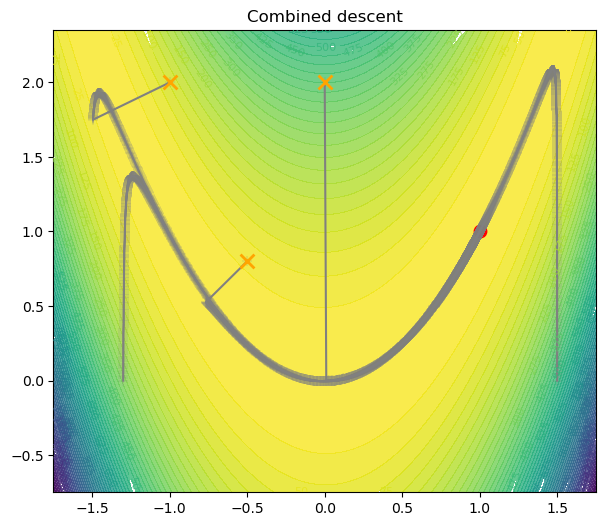

In [21]:
plt.figure(figsize=(7, 6))
contours = plt.contourf(X, Y, Z, levels=70, cmap=cm.viridis_r, alpha=0.8)
plt.clabel(contours, inline=True, fontsize=8)

plt.plot(path_13[:,0], path_13[:,1], color='gray', marker="+", markersize=7, markeredgewidth=0.2, label=f"x0=(-0.5, 0.8)")
plt.plot(path_14[:,0], path_14[:,1], color='gray', marker="+", markersize=7, markeredgewidth=0.2, label=f"x0=(-1,2)")
plt.plot(path_15[:,0], path_15[:,1], color='gray', marker="+", markersize=7, markeredgewidth=0.2, label=f"x0=(1.5, 0)")
plt.plot(path_16[:,0], path_16[:,1], color='gray', marker="+", markersize=7, markeredgewidth=0.2, label=f"x0=(0, 2)")
plt.plot(path_17[:,0], path_17[:,1], color='gray', marker="+", markersize=7, markeredgewidth=0.2, label=f"x0=(0.7,0.5)")
plt.plot(path_18[:,0], path_18[:,1], color='gray', marker="+", markersize=7, markeredgewidth=0.2, label=f"x0=(-1.3,0)")

# Add orange crosses at starting points
plt.scatter(path_13[0,0], path_13[0,1], color='orange', marker='x', s=100, linewidths=2, zorder=5)
plt.scatter(path_14[0,0], path_14[0,1], color='orange', marker='x', s=100, linewidths=2, zorder=5)
plt.scatter(path_16[0,0], path_16[0,1], color='orange', marker='x', s=100, linewidths=2, zorder=5)

plt.scatter(1,1,color="red",s=80,label="minimum: (1,1)")
# plt.legend(loc = 'upper right', fontsize=8)
plt.title("Combined descent")
plt.show()

To conclude, we show this final plot where the same points followed by the combined algorithm are represented once again.  
This time, orange crosses mark the points where the next iteration was performed using **gradient descent**, and grey crosses mark those where the **Newton method** was applied.  
We can observe that the only three points where gradient descent was used correspond to regions where the function is **concave**.  
In these cases, the Hessian matrix is **not positive definite**, and therefore the Newton method fails to provide a valid descent direction.
